In [1]:
import os, re, numpy as np, pandas as pd, torch, pickle, warnings
from torch.utils.data import Dataset, DataLoader, TensorDataset
from momentfm import MOMENTPipeline
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
from collections import defaultdict

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*IProgress.*")

DATA_DIR = "../TSB-AD-M"
WINDOW_SIZE = 512
TEST_STEP = 512
TRAIN_STEP = 64
BATCH_SIZE = 16
BATCH_SIZE_FT = 16
EPOCHS_FT = 5
LR_FT = 1e-4
WEIGHT_DECAY = 1e-5
SMOOTHNESS_LAMBDA = 0.1
PATIENCE = 3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == 'cuda'

USE_NORMALIZATION = False
SMOOTHING_WINDOW = 11
USE_DYNAMIC_THRESHOLD = False

D:\Учёба\Учёба ВШЭ\2 семестр\Курсач\.venv1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def parse_tr_len(fname):
    m = re.search(r'_tr_(\d+)_', fname)
    if m is None:
        raise ValueError(f"Cannot parse tr_len in {fname}")
    return int(m.group(1))


def get_dataset_name(fname):
    for ds in ["MSL", "MITDB", "SMAP", "SMD", "LTDB", "SVDB", "SWaT"]:
        if ds in fname:
            return ds
    raise ValueError(f"Unknown dataset for {fname}")


def point_adjustment(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    y_pred_pa = y_pred.copy()
    seg_start = None
    segments = []
    for i in range(len(y_true)):
        if y_true[i] == 1 and seg_start is None:
            seg_start = i
        elif y_true[i] == 0 and seg_start is not None:
            segments.append((seg_start, i))
            seg_start = None
    if seg_start is not None:
        segments.append((seg_start, len(y_true)))
    for s, e in segments:
        if np.any(y_pred[s:e] == 1):
            y_pred_pa[s:e] = 1
    return y_pred_pa


def normalize_series(train_data, test_data):
    mean = np.mean(train_data, axis=0, keepdims=True)
    std = np.std(train_data, axis=0, keepdims=True)
    std[std < 1e-8] = 1.0  # защита от деления на ноль
    train_norm = (train_data - mean) / std
    test_norm = (test_data - mean) / std
    return train_norm, test_norm, mean, std


def median_smoothing(scores, window=11):
    if window < 3 or window % 2 == 0:
        return scores
    from scipy.signal import medfilt
    return medfilt(scores, kernel_size=window)


def dynamic_threshold(scores, window_size=100, n_std=3.0):
    if len(scores) < window_size:
        return np.mean(scores) + n_std * np.std(scores)
    thresholds = []
    for i in range(window_size, len(scores) + 1):
        window = scores[i - window_size:i]
        th = np.mean(window) + n_std * np.std(window)
        thresholds.append(th)
    return np.median(thresholds)

In [3]:
class SimpleTestDataset(Dataset):
    def __init__(self, data, window_size=512, step=256):
        self.data = data.astype(np.float32)
        self.window_size = window_size
        self.step = step
        self.indices = list(range(0, self.data.shape[0] - window_size + 1, step))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        start = self.indices[idx]
        end = start + self.window_size
        x = self.data[start:end].T
        return torch.from_numpy(x), start


class SimpleTrainDataset(Dataset):
    def __init__(self, data, window_size=512, step=256):
        self.data = data.astype(np.float32)
        self.window_size = window_size
        self.step = step
        self.indices = list(range(0, self.data.shape[0] - window_size + 1, step))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        start = self.indices[idx]
        end = start + self.window_size
        x = self.data[start:end].T
        return torch.from_numpy(x)

In [4]:
def aggregate_predictions(model, test_ds, total_len, batch_size=16):
    model.eval()
    C = test_ds.data.shape[1]
    sum_recon = np.zeros((total_len, C))
    sum_sq_diff = np.zeros(total_len)
    counts = np.zeros(total_len)

    loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for batch in tqdm(loader, desc="  Inference", leave=False):
            batch_x = batch[0].to(DEVICE)
            starts = batch[1].tolist()
            seq_len = batch_x.shape[-1]
            input_mask = torch.ones(batch_x.shape[0], seq_len, device=DEVICE)
            if USE_AMP:
                with torch.amp.autocast('cuda'):
                    recon = model(x_enc=batch_x, input_mask=input_mask).reconstruction
            else:
                recon = model(x_enc=batch_x, input_mask=input_mask).reconstruction
            recon = recon.cpu().numpy()
            for i, start in enumerate(starts):
                end_win = start + WINDOW_SIZE
                sum_recon[start:end_win] += recon[i].T
                error = np.mean((batch_x[i].cpu().numpy().T - recon[i].T) ** 2, axis=1)
                sum_sq_diff[start:end_win] += error
                counts[start:end_win] += 1

    recon_full = np.full((total_len, C), np.nan)
    scores = np.full(total_len, np.nan)
    valid = counts > 0
    recon_full[valid] = sum_recon[valid] / counts[valid, np.newaxis]
    scores[valid] = sum_sq_diff[valid] / counts[valid]
    recon_full = np.apply_along_axis(lambda c: np.interp(np.arange(total_len),
                                                         np.where(valid)[0], c[valid]), axis=0, arr=recon_full)
    scores = np.interp(np.arange(total_len), np.where(valid)[0], scores[valid])
    return recon_full, scores


def fine_tune_model_from_loader(model, train_loader, val_loader=None, epochs=EPOCHS_FT, lr=LR_FT,
                                weight_decay=WEIGHT_DECAY, smoothness_lambda=SMOOTHNESS_LAMBDA, patience=PATIENCE):
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion_mse = torch.nn.MSELoss()

    best_val_loss = float('inf')
    wait = 0
    for epoch in range(epochs):
        total_loss = 0.0
        for batch in train_loader:
            if isinstance(batch, (tuple, list)):
                batch_x = batch[0]
            else:
                batch_x = batch
            batch_x = batch_x.to(DEVICE)
            seq_len = batch_x.shape[-1]
            input_mask = torch.ones(batch_x.shape[0], seq_len, device=DEVICE)
            optimizer.zero_grad()
            if USE_AMP:
                with torch.amp.autocast('cuda'):
                    recon = model(x_enc=batch_x, input_mask=input_mask).reconstruction
                    mse_loss = criterion_mse(recon, batch_x)
                    # Loss гладкости: разница между соседними точками во временном измерении
                    if smoothness_lambda > 0:
                        diff_recon = recon[:, :, 1:] - recon[:, :, :-1]
                        smooth_loss = torch.mean(diff_recon ** 2)
                        loss = mse_loss + smoothness_lambda * smooth_loss
                    else:
                        loss = mse_loss
                loss.backward()
            else:
                recon = model(x_enc=batch_x, input_mask=input_mask).reconstruction
                mse_loss = criterion_mse(recon, batch_x)
                if smoothness_lambda > 0:
                    diff_recon = recon[:, :, 1:] - recon[:, :, :-1]
                    smooth_loss = torch.mean(diff_recon ** 2)
                    loss = mse_loss + smoothness_lambda * smooth_loss
                else:
                    loss = mse_loss
                loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        print(f"    Epoch {epoch + 1}/{epochs}, Train loss: {avg_train_loss:.6f}")

        if val_loader is not None:
            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for batch in val_loader:
                    if isinstance(batch, (tuple, list)):
                        batch_x = batch[0]
                    else:
                        batch_x = batch
                    batch_x = batch_x.to(DEVICE)
                    seq_len = batch_x.shape[-1]
                    input_mask = torch.ones(batch_x.shape[0], seq_len, device=DEVICE)
                    recon = model(x_enc=batch_x, input_mask=input_mask).reconstruction
                    loss = criterion_mse(recon, batch_x)
                    val_loss += loss.item()
            avg_val_loss = val_loss / len(val_loader)
            print(f"      Val loss: {avg_val_loss:.6f}")
            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                wait = 0
            else:
                wait += 1
                if wait >= patience:
                    print(f"      Early stopping at epoch {epoch + 1}")
                    break
            model.train()
        else:
            pass

    model.eval()


all_files = [f for f in os.listdir(DATA_DIR) if f.endswith('.csv') and 'TSB-AD-M' not in f]
print(f"Found {len(all_files)} CSV files.")

grouped_files = defaultdict(list)
file_info = {}

for fname in all_files:
    ds = get_dataset_name(fname)
    filepath = os.path.join(DATA_DIR, fname)
    df = pd.read_csv(filepath).dropna()
    tr_len = parse_tr_len(fname)
    data_raw = df.iloc[:, :-1].values.astype(np.float32)
    labels = df['Label'].astype(np.int64).values

    train_raw = data_raw[:tr_len]
    test_raw = data_raw[tr_len:]

    if USE_NORMALIZATION:
        train_norm, test_norm, mean, std = normalize_series(train_raw, test_raw)
        data_norm = np.vstack([train_norm, test_norm]) if len(test_norm) > 0 else train_norm
        data = data_norm
    else:
        data = data_raw

    n_features = data.shape[1]
    key = (ds, n_features)
    grouped_files[key].append(fname)
    file_info[fname] = {
        'data': data,
        'labels': labels,
        'tr_len': tr_len,
        'n_features': n_features,
        'mean_std': (mean, std) if USE_NORMALIZATION else None
    }

results_per_series = {}
plot_data = {}

for (ds, n_feat), fnames in tqdm(grouped_files.items(), desc="Processing groups"):
    print(f"\nProcessing group: {ds}, features={n_feat} ({len(fnames)} files)")

    all_train_windows = []
    for fname in fnames:
        info = file_info[fname]
        train_data = info['data'][:info['tr_len']]
        if len(train_data) >= WINDOW_SIZE:
            ds_train = SimpleTrainDataset(train_data, WINDOW_SIZE, step=TRAIN_STEP)
            for i in range(len(ds_train)):
                all_train_windows.append(ds_train[i])

    if not all_train_windows:
        print("  No training windows -> skip fine-tuning, use pretrained")
        model = MOMENTPipeline.from_pretrained(
            "AutonLab/MOMENT-1-large",
            model_kwargs={"task_name": "reconstruction"}
        )
        model.init()
        model = model.to(DEVICE).float()
        model.eval()
    else:
        print(f"  Total training windows: {len(all_train_windows)}")
        # Разделение на train / val (90/10)
        n_val = max(1, int(0.1 * len(all_train_windows)))
        train_windows, val_windows = all_train_windows[n_val:], all_train_windows[:n_val]
        train_tensor = torch.stack(train_windows)
        val_tensor = torch.stack(val_windows) if len(val_windows) > 0 else None

        train_dataset = TensorDataset(train_tensor)
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE_FT, shuffle=True)
        val_loader = DataLoader(TensorDataset(val_tensor), batch_size=BATCH_SIZE_FT,
                                shuffle=False) if val_tensor is not None else None

        model = MOMENTPipeline.from_pretrained(
            "AutonLab/MOMENT-1-large",
            model_kwargs={"task_name": "reconstruction"}
        )
        model.init()
        model = model.to(DEVICE).float()
        print("  Starting fine-tuning (with smoothness loss & early stopping)...")
        fine_tune_model_from_loader(model, train_loader, val_loader, epochs=EPOCHS_FT, lr=LR_FT,
                                    weight_decay=WEIGHT_DECAY, smoothness_lambda=SMOOTHNESS_LAMBDA,
                                    patience=PATIENCE)

    for fname in fnames:
        info = file_info[fname]
        test_data = info['data'][info['tr_len']:]
        test_labels = info['labels'][info['tr_len']:]
        if len(test_data) < WINDOW_SIZE:
            continue

        test_ds = SimpleTestDataset(test_data, WINDOW_SIZE, TEST_STEP)
        recon, scores_raw = aggregate_predictions(model, test_ds, len(test_data), BATCH_SIZE)

        scores_raw = (scores_raw - np.min(scores_raw)) / (np.max(scores_raw) - np.min(scores_raw) + 1e-10)

        if SMOOTHING_WINDOW > 0 and SMOOTHING_WINDOW % 2 == 1:
            scores = median_smoothing(scores_raw, window=SMOOTHING_WINDOW)
        else:
            scores = scores_raw

        if len(np.unique(test_labels)) == 2:
            best_f1 = -1.0
            best_thr = 0.0
            for thr in np.unique(scores):
                preds = (scores >= thr).astype(int)
                tp = np.sum((test_labels == 1) & (preds == 1))
                fp = np.sum((test_labels == 0) & (preds == 1))
                fn = np.sum((test_labels == 1) & (preds == 0))
                prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
                rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
                f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
                if f1 > best_f1:
                    best_f1 = f1
                    best_thr = thr
            y_pred = (scores >= best_thr).astype(int)
        else:
            best_thr = 0.0
            y_pred = np.ones(len(scores), dtype=int)

        tp = np.sum((test_labels == 1) & (y_pred == 1))
        fp = np.sum((test_labels == 0) & (y_pred == 1))
        fn = np.sum((test_labels == 1) & (y_pred == 0))
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0

        y_pred_pa = point_adjustment(test_labels, y_pred)
        tp_pa = np.sum((test_labels == 1) & (y_pred_pa == 1))
        fp_pa = np.sum((test_labels == 0) & (y_pred_pa == 1))
        fn_pa = np.sum((test_labels == 1) & (y_pred_pa == 0))
        prec_pa = tp_pa / (tp_pa + fp_pa) if (tp_pa + fp_pa) > 0 else 0.0
        rec_pa = tp_pa / (tp_pa + fn_pa) if (tp_pa + fn_pa) > 0 else 0.0
        f1_pa = 2 * prec_pa * rec_pa / (prec_pa + rec_pa) if (prec_pa + rec_pa) > 0 else 0.0

        roc_auc = roc_auc_score(test_labels, scores) if len(np.unique(test_labels)) == 2 else np.nan
        rmse = np.sqrt(np.mean((test_data - recon) ** 2))
        mae = np.mean(np.abs(test_data - recon))

        metrics_dict = {
            'f1': f1, 'precision': prec, 'recall': rec,
            'f1_pa': f1_pa, 'precision_pa': prec_pa, 'recall_pa': rec_pa,
            'roc_auc': roc_auc,
            'rmse': rmse, 'mae': mae,
            'threshold': best_thr,
        }

        if USE_DYNAMIC_THRESHOLD and len(np.unique(test_labels)) == 2:
            dyn_thr = dynamic_threshold(scores, window_size=100, n_std=3.0)
            y_pred_dyn = (scores >= dyn_thr).astype(int)
            tp_dyn = np.sum((test_labels == 1) & (y_pred_dyn == 1))
            fp_dyn = np.sum((test_labels == 0) & (y_pred_dyn == 1))
            fn_dyn = np.sum((test_labels == 1) & (y_pred_dyn == 0))
            prec_dyn = tp_dyn / (tp_dyn + fp_dyn) if (tp_dyn + fp_dyn) > 0 else 0.0
            rec_dyn = tp_dyn / (tp_dyn + fn_dyn) if (tp_dyn + fn_dyn) > 0 else 0.0
            f1_dyn = 2 * prec_dyn * rec_dyn / (prec_dyn + rec_dyn) if (prec_dyn + rec_dyn) > 0 else 0.0
            metrics_dict['f1_dynamic'] = f1_dyn
            metrics_dict['threshold_dynamic'] = dyn_thr

        results_per_series.setdefault(ds, []).append(metrics_dict)

        se = {
            'trues_full': test_data,
            'preds_full': recon,
            'labels_full': test_labels,
            'anomaly_scores': scores,
            'total_length': len(test_data),
            'optimal_threshold': best_thr,
            'file': fname
        }
        plot_data.setdefault(ds, []).append(se)

dataset_summary = []
for ds in ["MSL", "MITDB", "SMAP", "SMD", "LTDB", "SVDB", "SWaT"]:
    if ds not in results_per_series:
        continue
    df = pd.DataFrame(results_per_series[ds])
    numeric = df.select_dtypes(include=[np.number])
    avg = numeric.mean()
    avg['dataset'] = ds
    dataset_summary.append(avg)

summary_df = pd.DataFrame(dataset_summary).set_index('dataset')
print("\n" + "=" * 80)
print("MODERNIZED: Normalization + Smoothing + Smoothness Loss + Early Stopping")
print("Fine-tuned MOMENT – average metrics per dataset:")
print(summary_df)

with open("../finetuned_moment_modernized.pkl", "wb") as f:
    pickle.dump({
        'per_series': results_per_series,
        'per_dataset_avg': summary_df,
        'plot_data': plot_data,
        'config': {
            'normalization': USE_NORMALIZATION,
            'smoothing_window': SMOOTHING_WINDOW,
            'smoothness_lambda': SMOOTHNESS_LAMBDA,
            'weight_decay': WEIGHT_DECAY,
        }
    }, f)
print("\nResults saved to finetuned_moment_modernized.pkl")

Found 116 CSV files.


Processing groups:   0%|          | 0/9 [00:00<?, ?it/s]


Processing group: MSL, features=55 (16 files)
  Total training windows: 75


  Starting fine-tuning (with smoothness loss & early stopping)...
    Epoch 1/5, Train loss: 0.003687
      Val loss: 0.001193
    Epoch 2/5, Train loss: 0.003662
      Val loss: 0.001188
    Epoch 3/5, Train loss: 0.004029
      Val loss: 0.001183
    Epoch 4/5, Train loss: 0.003578
      Val loss: 0.001178
    Epoch 5/5, Train loss: 0.003681
      Val loss: 0.001174



  Inference: 100%|██████████| 1/1 [00:00<00:00,  2.54it/s]
                                                          
  Inference: 100%|██████████| 1/1 [00:00<00:00,  1.01it/s]
                                                          
  Inference: 100%|██████████| 1/1 [00:00<00:00,  1.75it/s]
                                                          
  Inference: 100%|██████████| 1/1 [00:01<00:00,  1.00it/s]
                                                          
  Inference: 100%|██████████| 1/1 [00:01<00:00,  1.39s/it]
                                                          
  Inference: 100%|██████████| 1/1 [00:00<00:00,  1.01it/s]
                                                          
  Inference: 100%|██████████| 1/1 [00:00<00:00,  1.75it/s]
                                                          
  Inference: 100%|██████████| 1/1 [00:00<00:00,  1.26it/s]
                                                          
  Inference: 100%|██████████| 1/1 [00:00<00:00,  1.70it

...


Processing group: SWaT, features=66 (1 files)
  Total training windows: 51
  Starting fine-tuning (with smoothness loss & early stopping)...
    Epoch 1/5, Train loss: 4.420302
      Val loss: 5.721523
    Epoch 2/5, Train loss: 3.990927
      Val loss: 5.125051
    Epoch 3/5, Train loss: 3.670732
      Val loss: 4.585689
    Epoch 4/5, Train loss: 3.376392
      Val loss: 4.107701
    Epoch 5/5, Train loss: 3.009406
      Val loss: 3.694077



Processing groups:  89%|████████▉ | 8/9 [3:33:15<19:52, 1192.61s/it]


Processing group: SWaT, features=51 (1 files)
  Total training windows: 363
  Starting fine-tuning (with smoothness loss & early stopping)...
    Epoch 1/5, Train loss: 1.756790
      Val loss: 0.669896
    Epoch 2/5, Train loss: 1.027451
      Val loss: 0.438322
    Epoch 3/5, Train loss: 0.862800
      Val loss: 0.393396
    Epoch 4/5, Train loss: 0.835476
      Val loss: 0.377354
    Epoch 5/5, Train loss: 0.804754
      Val loss: 0.361987



Processing groups: 100%|██████████| 9/9 [3:57:38<00:00, 1584.31s/it]



MODERNIZED: Normalization + Smoothing + Smoothness Loss + Early Stopping
Fine-tuned MOMENT – average metrics per dataset:
               f1  precision    recall     f1_pa  precision_pa  recall_pa  \
dataset                                                                     
MSL      0.445452   0.518346  0.639224  0.677633      0.590823   1.000000   
MITDB    0.114809   0.102515  0.457407  0.353218      0.258468   1.000000   
SMAP     0.306925   0.352864  0.495212  0.565939      0.471014   1.000000   
SMD      0.436012   0.529875  0.496379  0.704099      0.643120   0.922558   
LTDB     0.302818   0.217203  0.683106  0.411366      0.284654   1.000000   
SVDB     0.173881   0.140965  0.359179  0.474503      0.344539   0.978819   
SWaT     0.267634   0.154898  1.000000  0.267634      0.154898   1.000000   

          roc_auc      rmse       mae  threshold  
dataset                                           
MSL      0.754245  0.145524  0.014480   0.103879  
MITDB    0.654533  0.044784  0

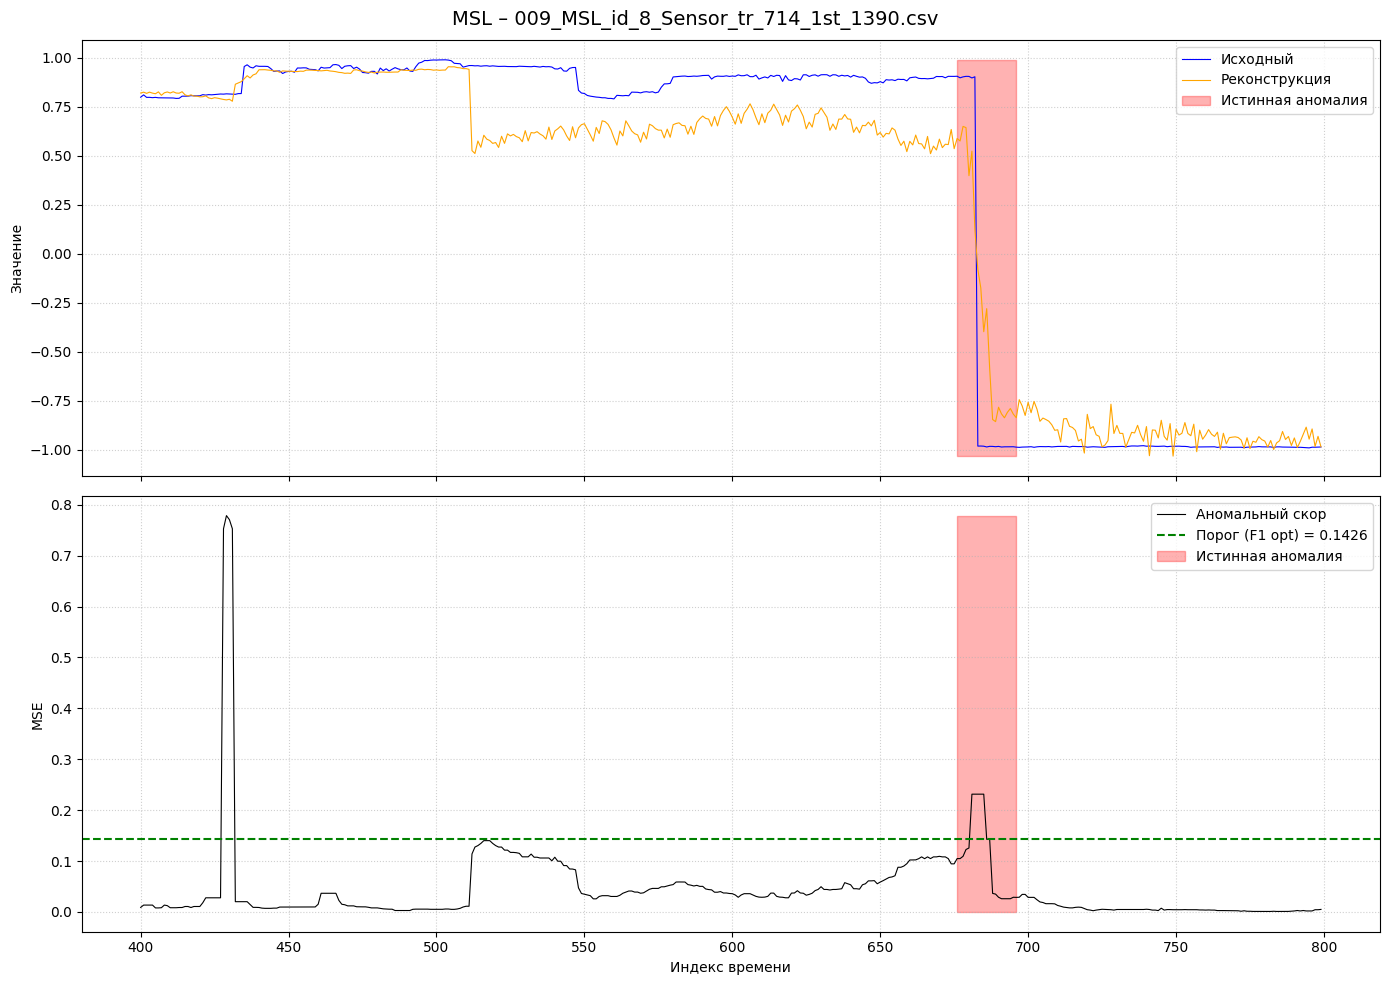

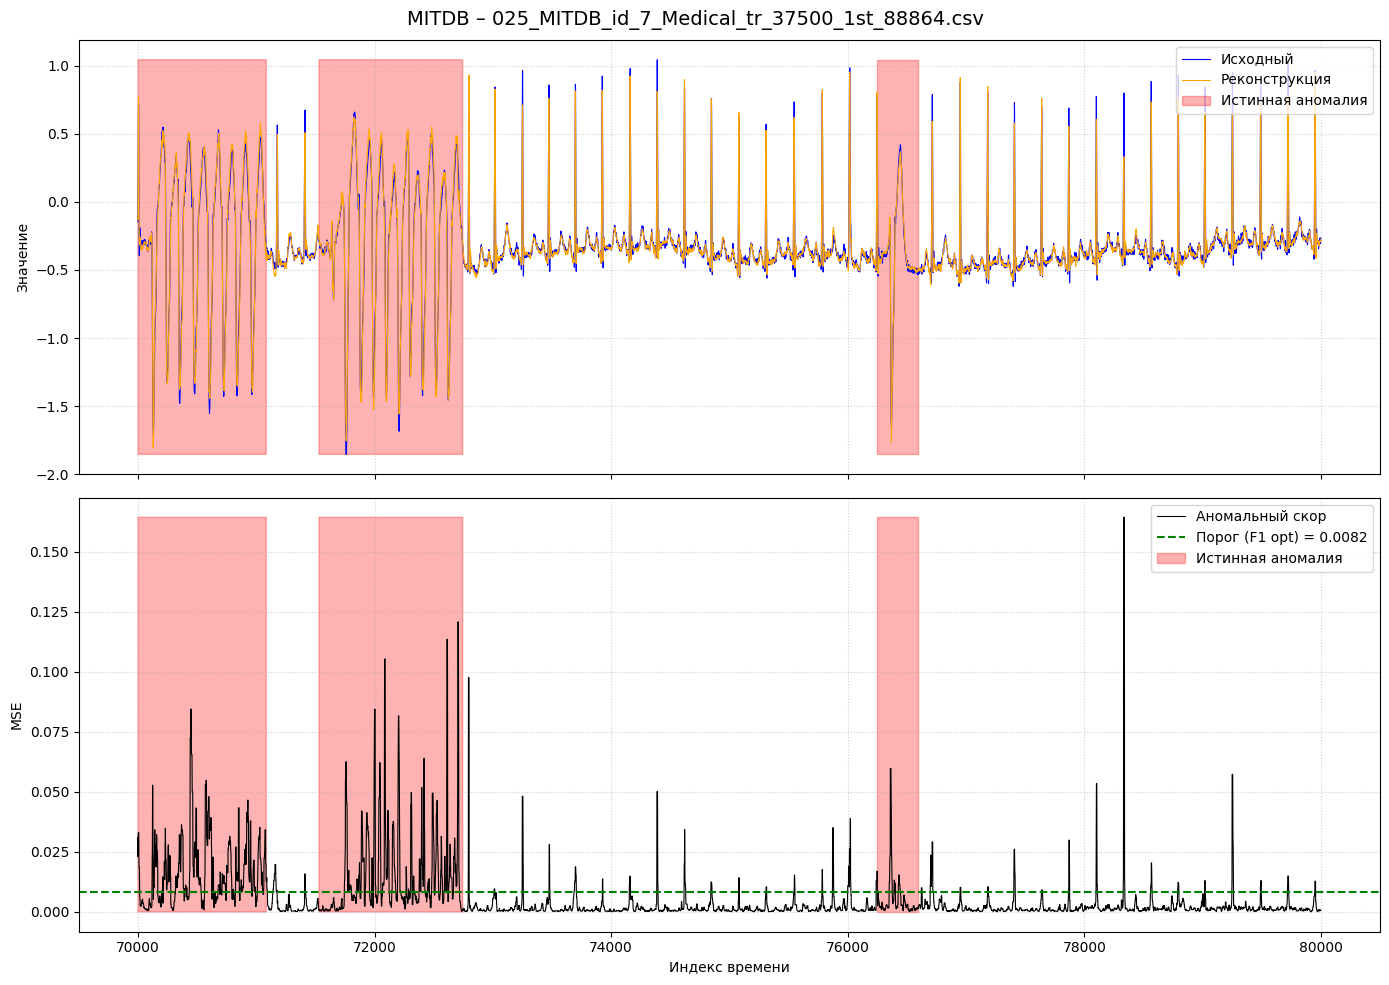

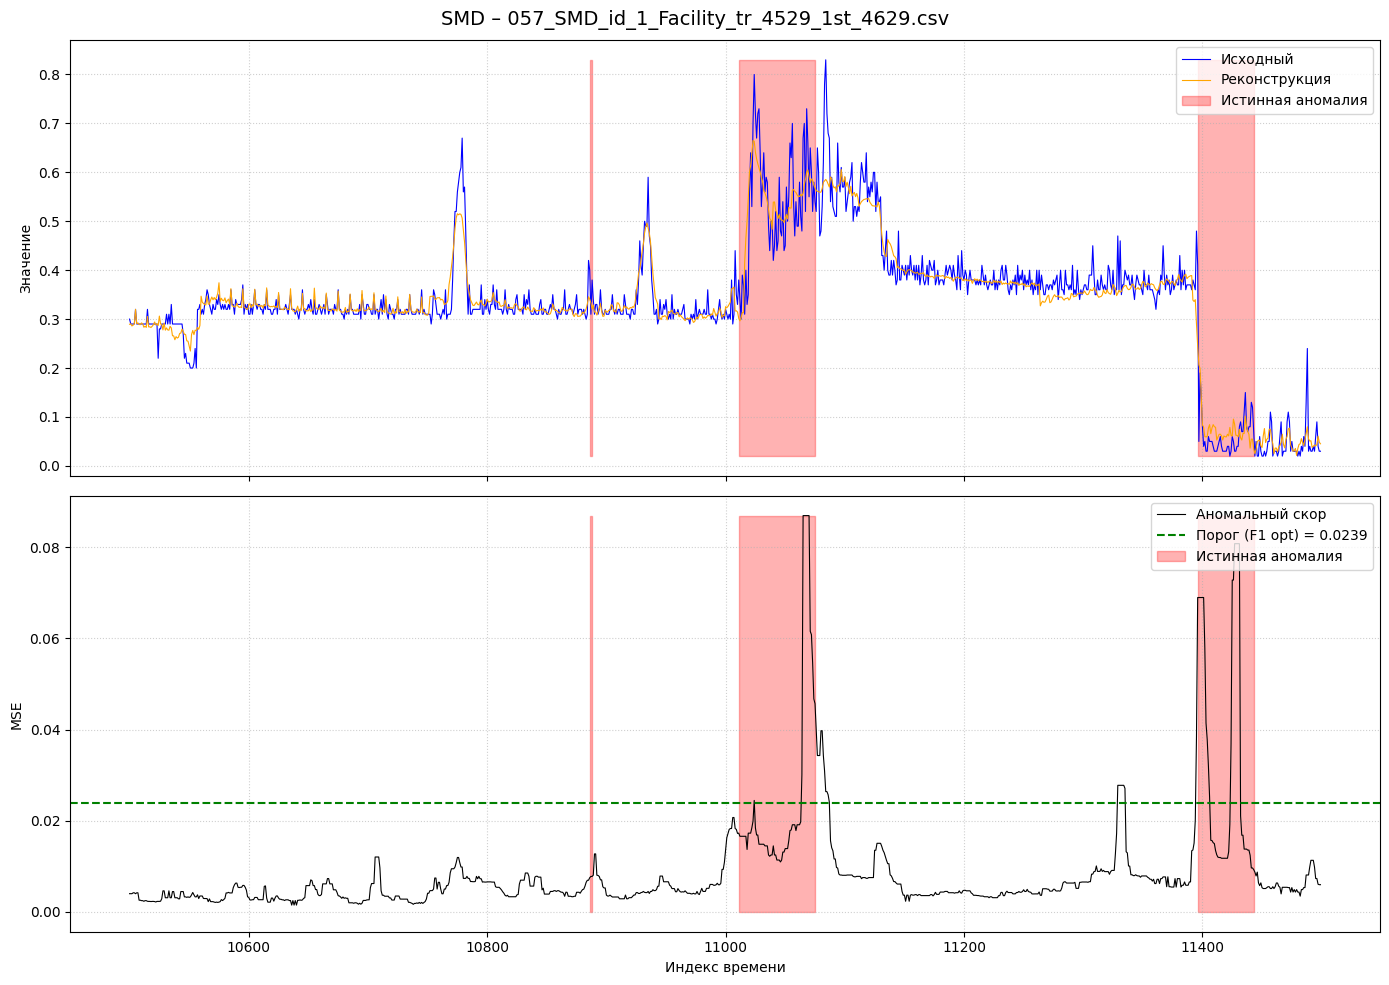

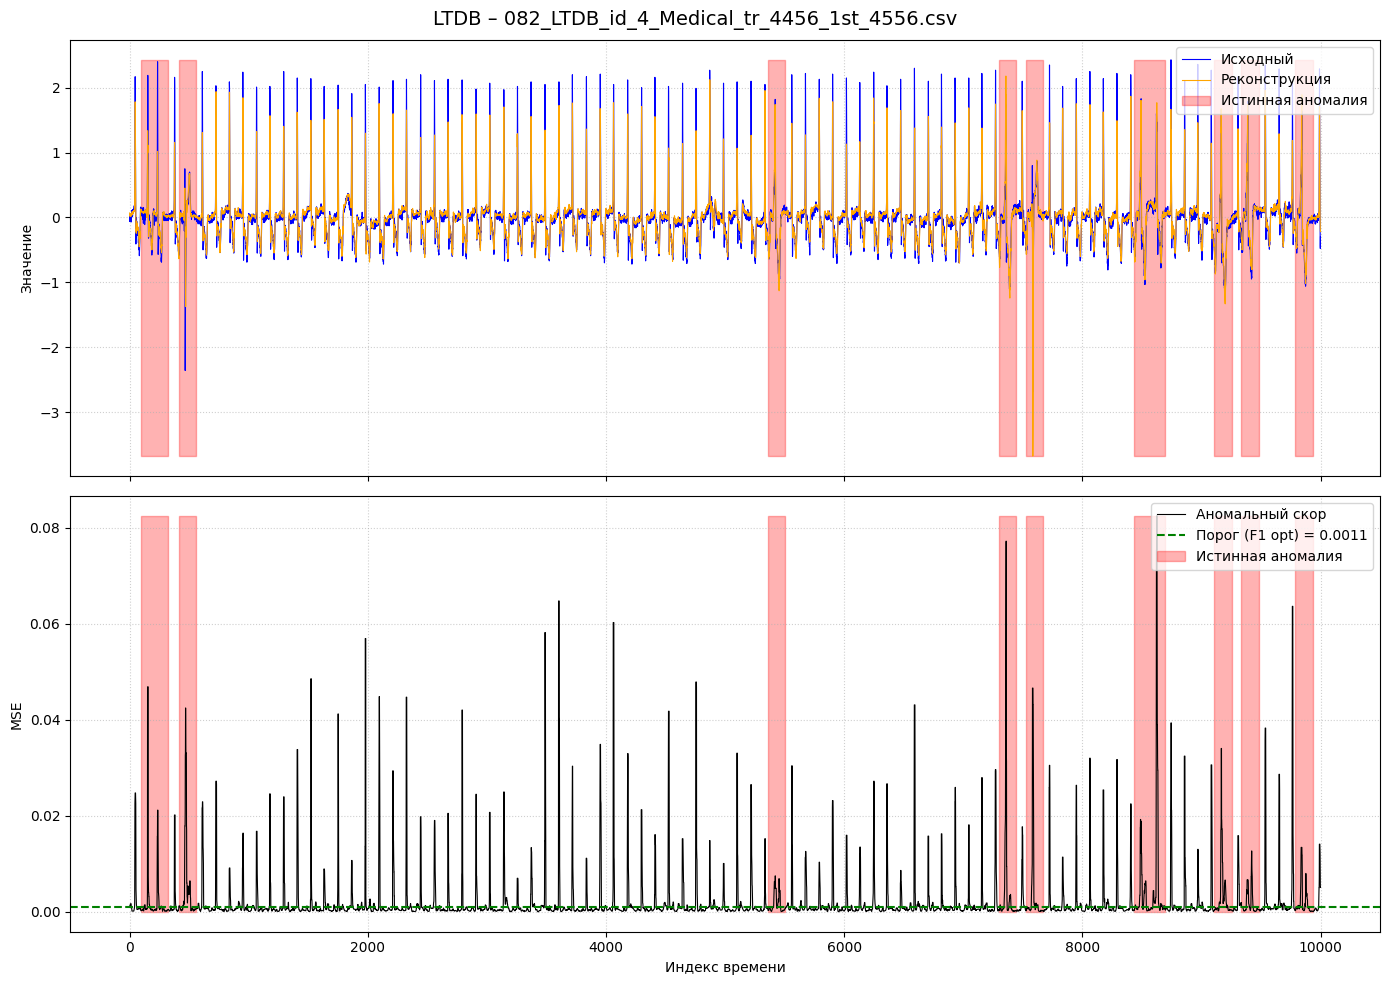

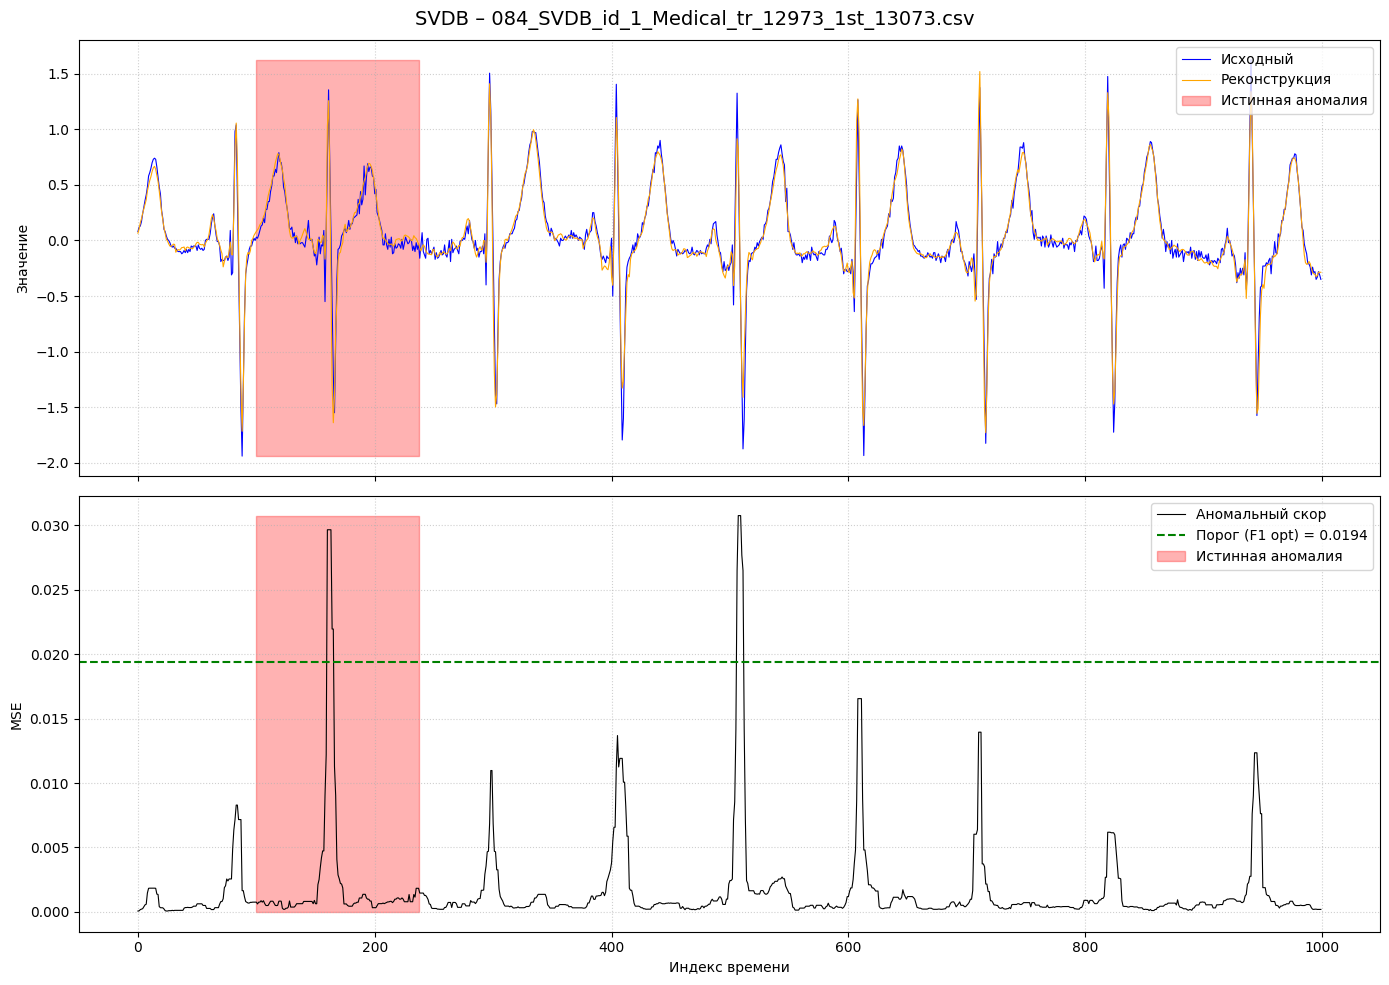

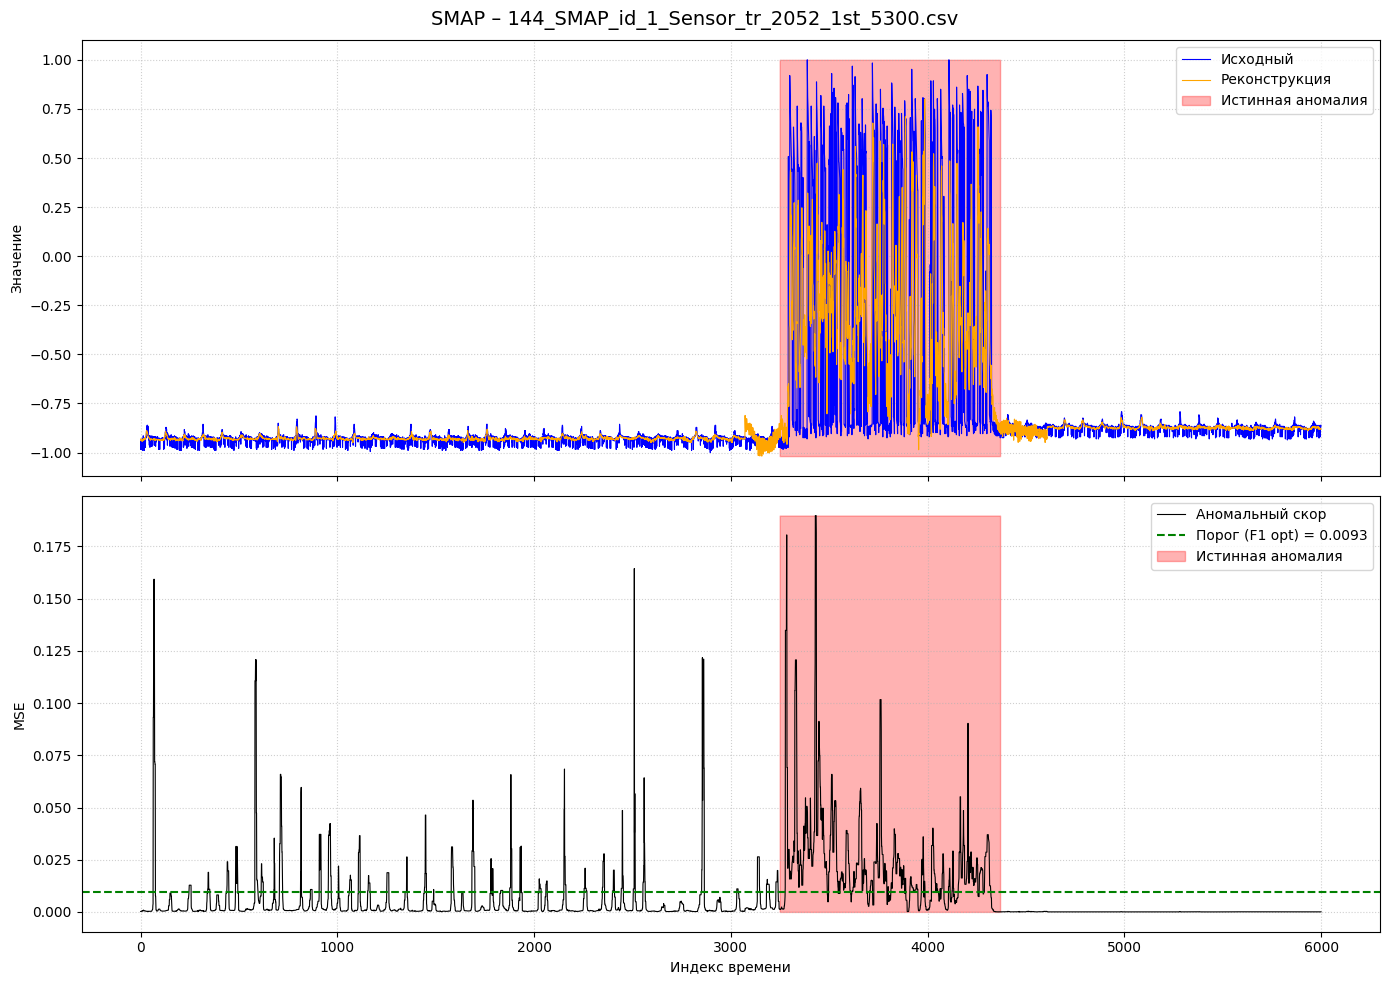

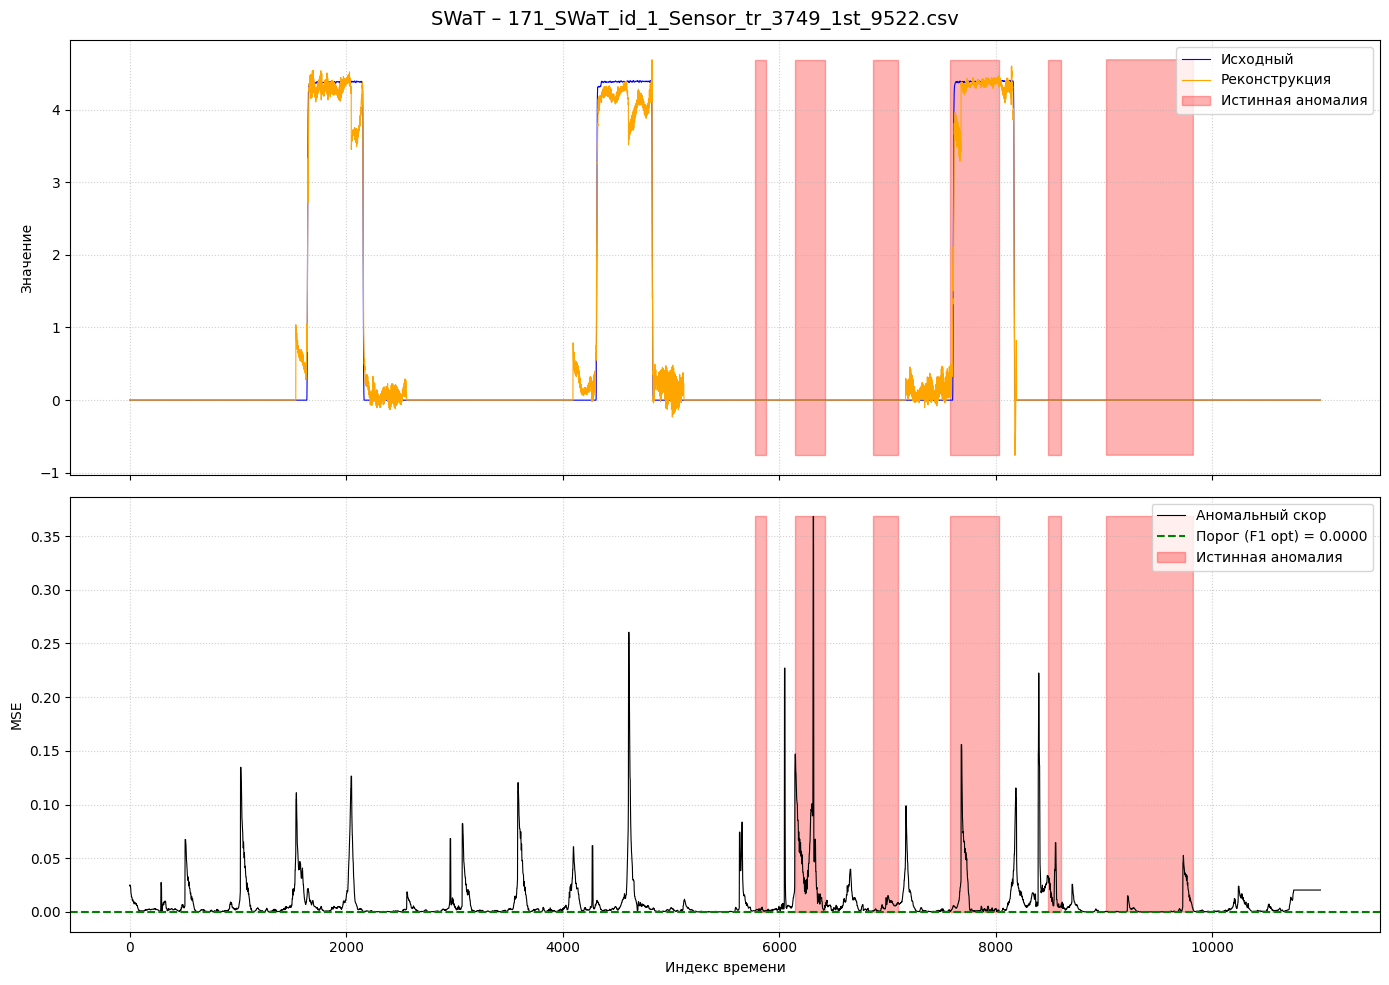

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve
import pickle

segments = {
    "MSL":
        {
            "start": 400,
            "end": 800,
        },
    "MITDB": {
            "start": 70_000,
            "end": 80_000,
    },
    "SMAP":
        {
            "start": 0,
            "end": 6000,
        },
    "SMD":
        {
            "start": 10500,
            "end": 11500,
        },
    "LTDB": {
            "start": 0,
            "end": 10000,
    },
    "SVDB": {
            "start": 0,
            "end": 1000,
    },
    "SWaT": {
            "start": 0,
            "end": 11000,
    }
}

# Загружаем сохранённые данные
with open("../finetuned_moment_modernized.pkl", "rb") as f:
    saved = pickle.load(f)
plot_data = saved['plot_data']  # словарь вида {dataset: [list of dicts]}

plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

window_display = 512

for ds_name, series_list in plot_data.items():
    # Возьмём первый ряд, в котором есть хотя бы одна аномалия
    chosen = None
    for se in series_list:
        if np.any(se['labels_full'] == 1):
            chosen = se
            break
    if chosen is None:
        chosen = series_list[0]

    if ds_name == "MSL":
        chosen = series_list[7]

    if ds_name == "MITDB":
        chosen = series_list[6]


    if ds_name == "LTDB":
        chosen = series_list[2]


    trues_full = chosen['trues_full']
    preds_full = chosen['preds_full']
    labels_full = chosen['labels_full']
    anomaly_scores = chosen['anomaly_scores']
    total_length = chosen['total_length']
    optimal_threshold = chosen['optimal_threshold']

    start, end = segments[ds_name]['start'], segments[ds_name]['end']

    time_axis = np.arange(start, end)

    fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    fig.suptitle(f"{ds_name} – {chosen['file']}", fontsize=14)

    ax = axes[0]
    ax.plot(time_axis, trues_full[start:end, 0], 'b-', linewidth=0.8, label='Исходный')
    ax.plot(time_axis, preds_full[start:end, 0], 'orange', linewidth=0.8, label='Реконструкция')
    ax.fill_between(time_axis,
                    min(trues_full[start:end, 0].min(), preds_full[start:end, 0].min()),
                    max(trues_full[start:end, 0].max(), preds_full[start:end, 0].max()),
                    where=(labels_full[start:end] == 1), color='red', alpha=0.3, label='Истинная аномалия')
    ax.set_ylabel('Значение')
    ax.legend(loc='upper right')
    ax.grid(True, linestyle=':', alpha=0.6)

    ax = axes[1]
    ax.plot(time_axis, anomaly_scores[start:end], 'k-', linewidth=0.8, label='Аномальный скор')
    ax.axhline(y=optimal_threshold, color='green', linestyle='--', linewidth=1.5,
               label=f'Порог (F1 opt) = {optimal_threshold:.4f}')
    ax.fill_between(time_axis, 0, anomaly_scores[start:end].max(),
                    where=(labels_full[start:end] == 1), color='red', alpha=0.3, label='Истинная аномалия')
    ax.set_xlabel('Индекс времени')
    ax.set_ylabel('MSE')
    ax.legend(loc='upper right')
    ax.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()
    # plt.savefig(f"{ds_name}_reconstruction_plot.png", dpi=150)